# Machine Learning Model Comparison and Analysis
### Objective
The objective of this project is to explore the complete lifecycle of building a machine learning model, from data preprocessing to feature selection, and ultimately comparing the performance of different machine learning algorithms. This will provide a practical understanding of how various techniques influence the outcomes and accuracy of predictive models.

### Dataset
The dataset used for this project is the ["Predict Students' Dropout and Academic Success"](https://www.kaggle.com/datasets/harshitsrivastava25/predict-students-dropout-and-academic-success) Dataset from Kaggle, which contains information on predicting student dropout and academic success in higher education institutions. It includes features academic path, demographics, and socio-economic factors,and more, along with a target variable (Target) Dropout , Graduate and Enrolled.


# Exploratory Data Analysis (EDA) & Preprocessing the data
*	Cleaning the dataset (handling missing values, removing duplicates, etc.).
*	Normalizing, scaling, or transforming data as needed.
*	Encoding categorical variables, if applicable.


##Data Exploration

In [ ]:
# import the nessessory libraries
import numpy as np # for mathmatical operations
import pandas as pd #used for data manipulation
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt # used for creating plot (visualisation)
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# Load data
student_data = pd.read_csv("/content/dataset.csv")

# Display the first 5 rows in a neatly formatted table
display(student_data.head())


In [ ]:
# target column values
student_data['Target'].value_counts()

In [ ]:
# Display basic data information
print("Dataset shape:", student_data.shape, "\n")
print("Dataset information:", student_data.info(), "\n")
print("Basic statistics:", student_data.describe())


In [ ]:
# for better understandig of the dataset
!pip install colorama tabulate

import pandas as pd
from tabulate import tabulate
from colorama import Fore, Back, Style

# Function to print unique values in a formatted table
def print_unique_values(df):
    table_data = [[col, ", ".join(map(str, df[col].unique()))] for col in df.columns]  # Collect unique values per column
    print(Back.LIGHTBLUE_EX + Fore.BLACK + " Unique Values in Each Feature " + Style.RESET_ALL)  # Header with blue background
    print(tabulate(table_data, headers=["Feature", "Unique Values"], tablefmt="fancy_grid"))  # Print table with grid style

# Call the function
print_unique_values(student_data)


 Unique Values in Each Feature 
╒════════════════════════════════════════════════╤══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical features
categorical_cols = student_data.select_dtypes(include=['object']).columns.tolist()

# Encode categorical features into numerical values using LabelEncoder
label_encoder = LabelEncoder()
for col in categorical_cols:
    student_data[col] = label_encoder.fit_transform(student_data[col])

# Identify numerical features after encoding
numerical_cols = student_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Display dataset summary
print("Observations:", student_data.shape[0])
print("Features:", student_data.shape[1])
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

# Display feature names
print("Categorical column names:", categorical_cols)
print("Numerical column names:", numerical_cols)


Observations: 4424
Features: 35
categorical_columns: 1
numerical_columns: 35
Categorical columns: ['Target']
Numerical columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluatio

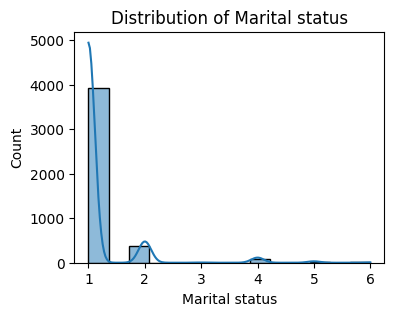

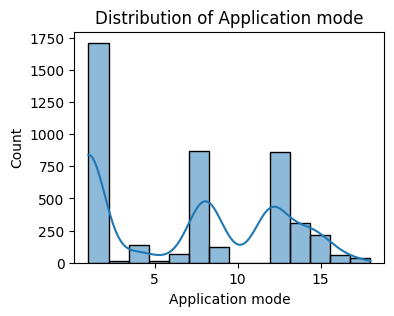

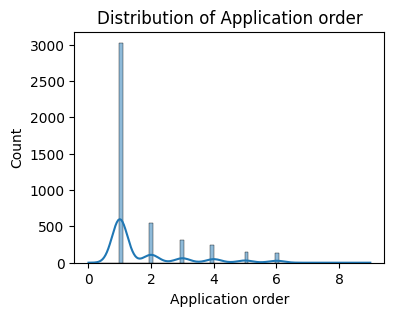

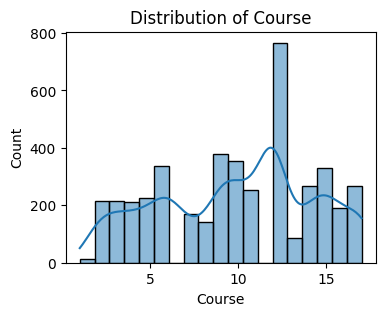

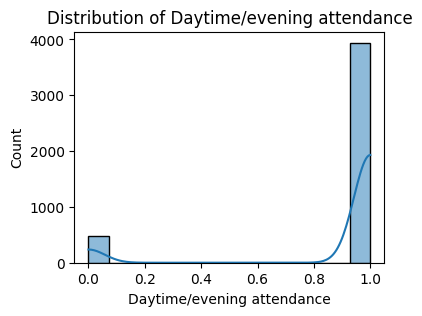

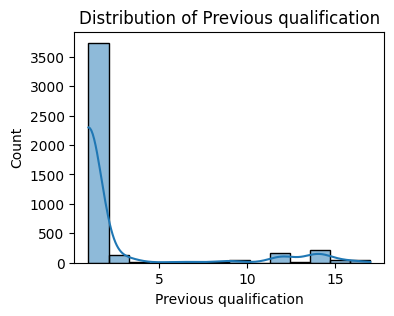

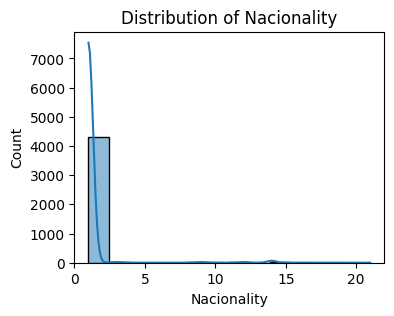

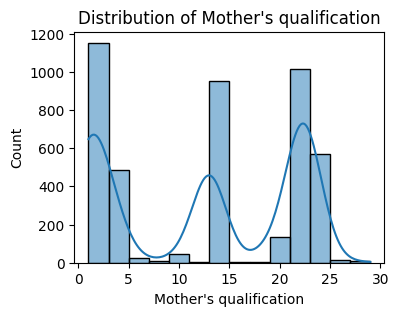

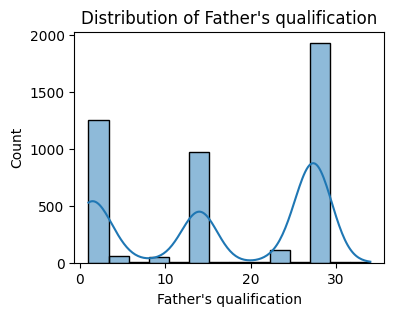

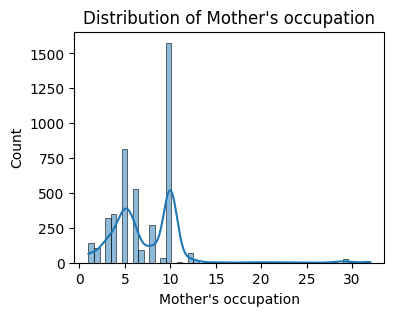

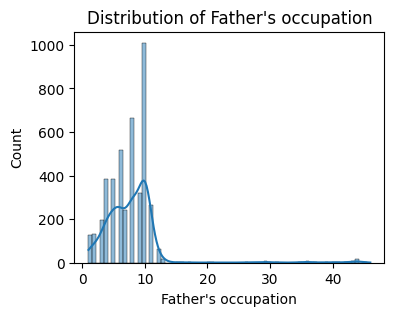

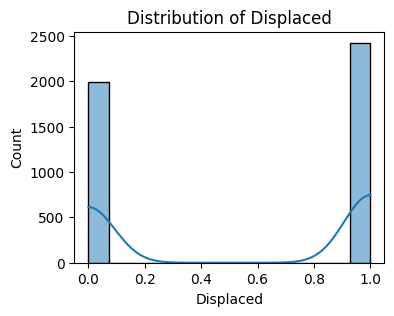

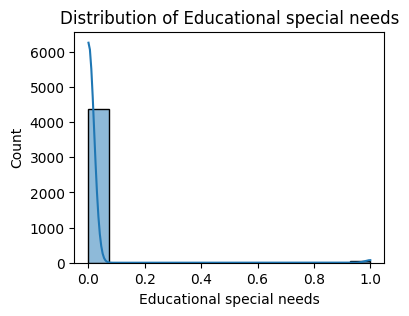

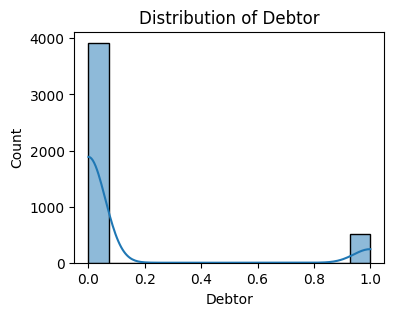

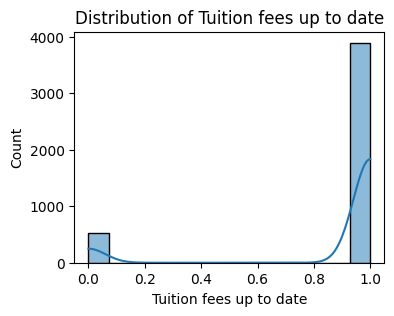

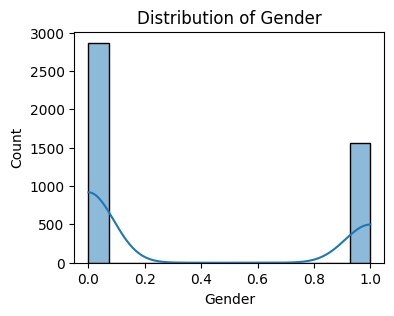

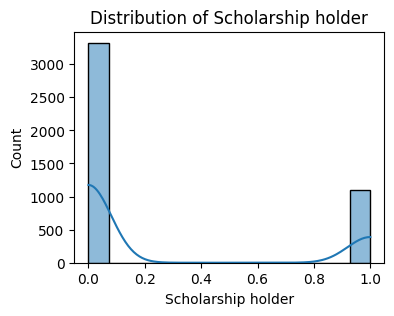

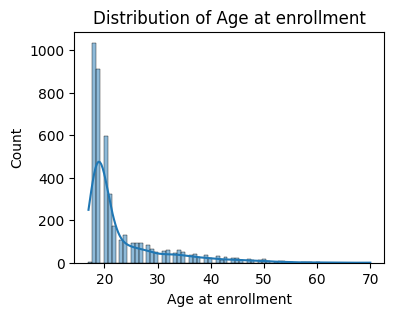

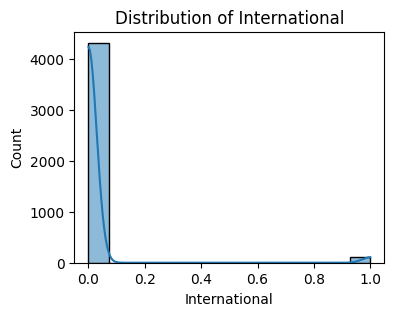

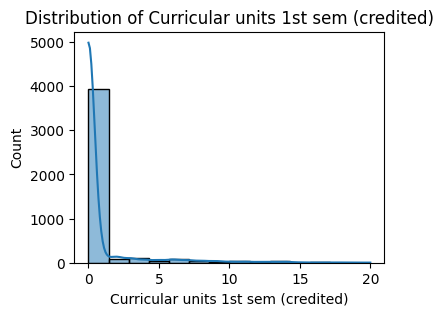

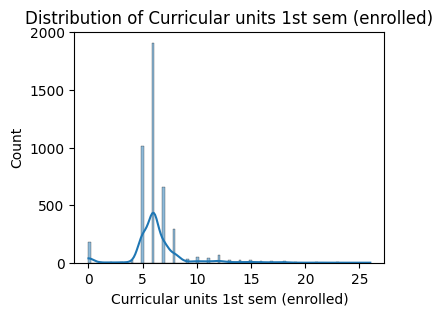

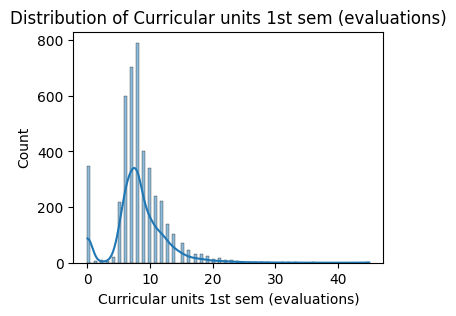

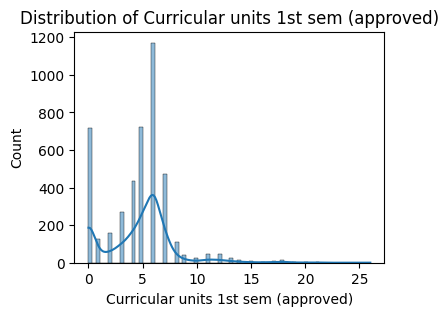

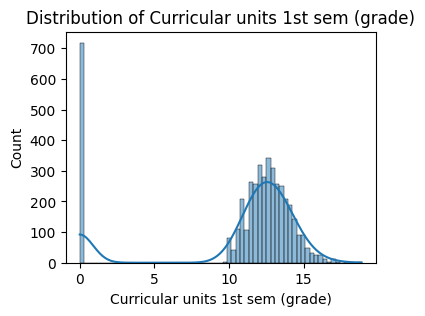

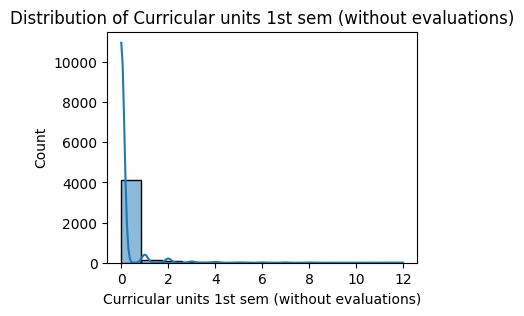

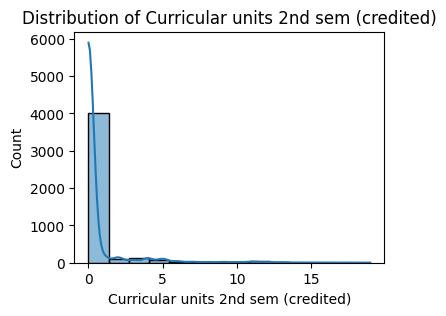

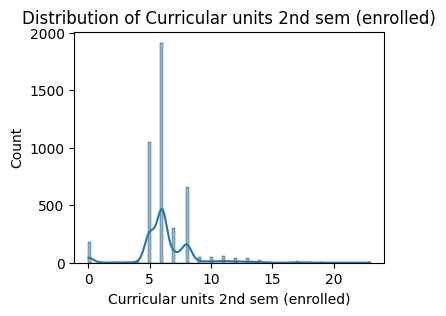

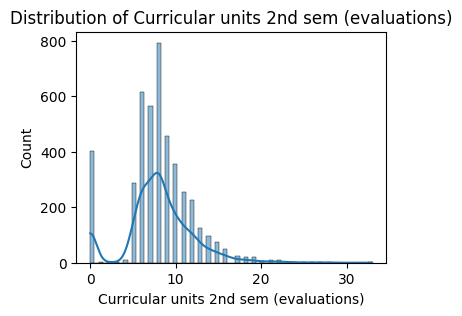

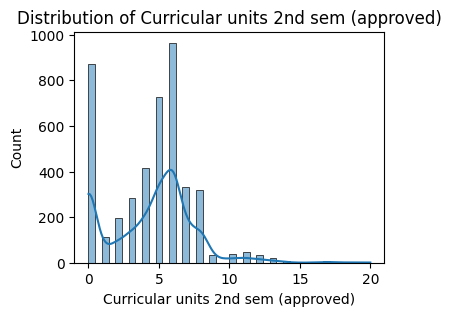

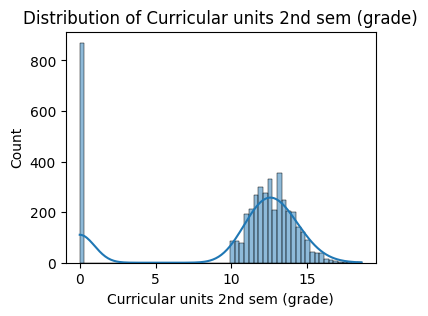

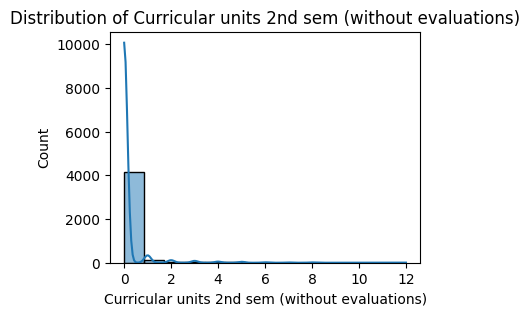

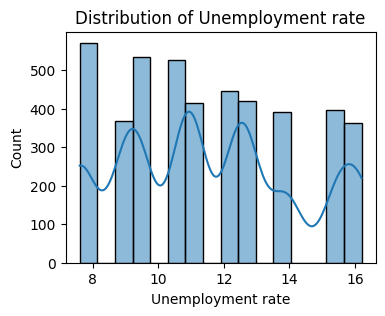

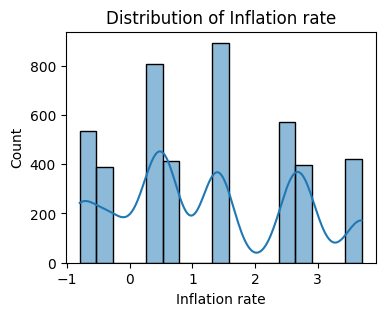

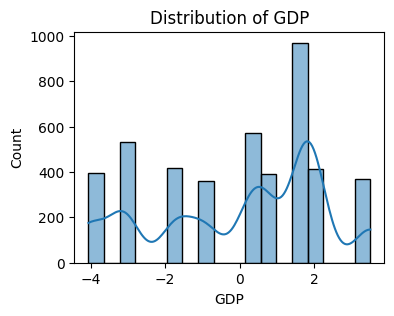

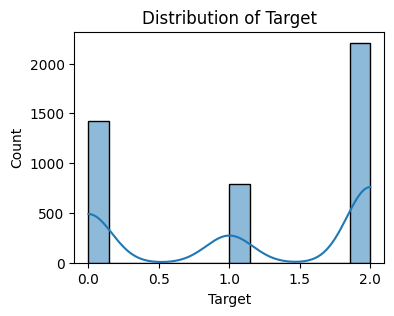

In [ ]:
# histograms to understand the distribution
for i in student_data.select_dtypes(include='number').columns:

    plt.figure(figsize=(4, 3))
    sns.histplot(student_data[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

##handling missing values

In [ ]:
# Check for missing values in the dataset

if student_data.isnull().values.any():
    print("There are missing values in the dataset.")

    # fill missing values by mean of the colomn if any exist
    student_data.fillna(student_data.mean(), inplace=True)
else:
    print("There are no missing values in the dataset.")


There are no missing values in the dataset.


##removing duplicates

In [ ]:
# Check for duplicates in the dataset
if student_data.duplicated().sum() > 0:
    print("Duplicates are:", student_data.duplicated().sum())
    # display the row's name of duplicates
    student_data[student_data.duplicated()]
    # Remove duplicates if any exist
    student_data_cleaned = student_data.drop_duplicates()
    # Check the shape of the dataset before removing duplicates
    print("Shape before removing duplicates:", student_data.shape)
    # Verify the shape after removing duplicates
    print("Shape after removing duplicates:", student_data_cleaned.shape)
else:
    print("No duplicates found.")

No duplicates found.


##Dealing with outliers

Columns in the data: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']

Number of outliers in each column:
Outliers 

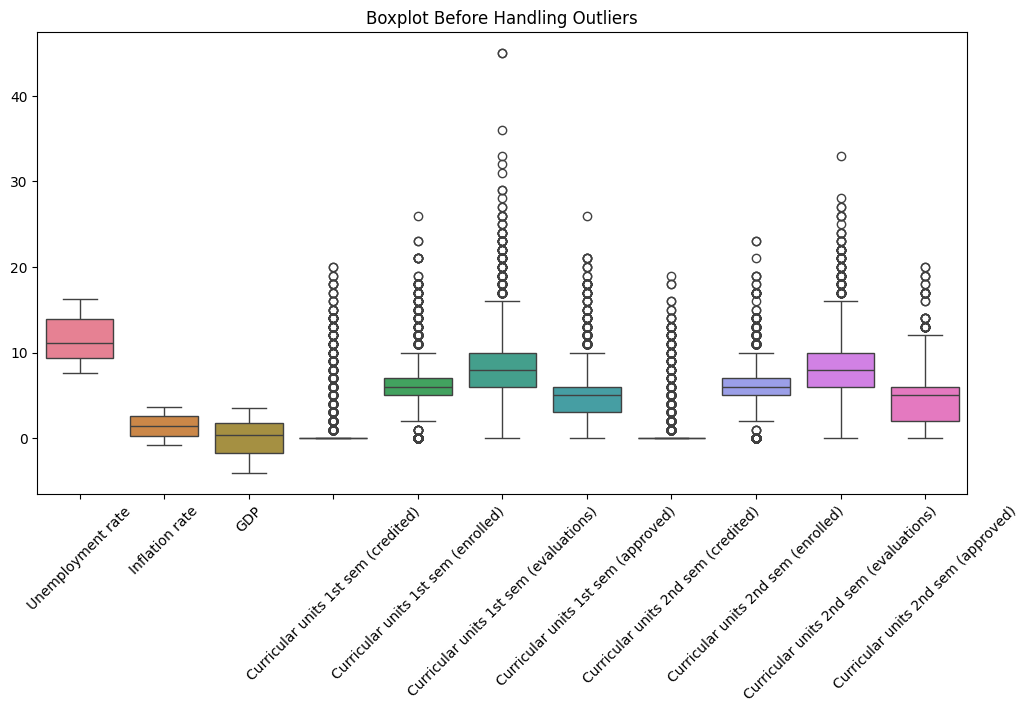

<ipython-input-11-3d10849eb21e>:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound



Boxplot after handling outliers:


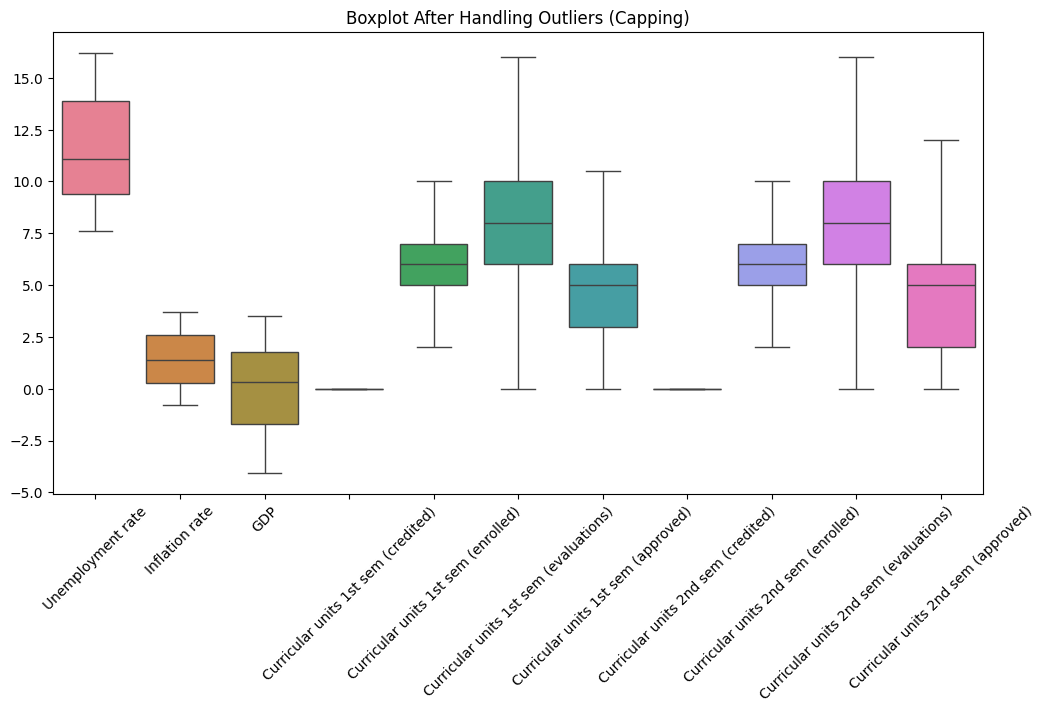


Number of outliers after handling (using capping):
Outliers in Unemployment rate: 0
Outliers in Inflation rate: 0
Outliers in GDP: 0
Outliers in Curricular units 1st sem (credited): 0
Outliers in Curricular units 1st sem (enrolled): 0
Outliers in Curricular units 1st sem (evaluations): 0
Outliers in Curricular units 1st sem (approved): 0
Outliers in Curricular units 2nd sem (credited): 0
Outliers in Curricular units 2nd sem (enrolled): 0
Outliers in Curricular units 2nd sem (evaluations): 0
Outliers in Curricular units 2nd sem (approved): 0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Display all column names in the dataset
print("Columns in the dataset:", student_data.columns.tolist())

# Define the numerical features to be analyzed
numerical_cols = [
    'Unemployment rate', 'Inflation rate', 'GDP',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)'
]

# Check whether all selected columns exist in the dataset
for col in numerical_cols:
    if col not in student_data.columns:
        print(f"Warning: Column '{col}' not found in the dataset!")

# Create a working copy of the dataset
data = student_data

# Function to detect outliers using the IQR method
def detect_outliers(data, columns):
    outliers_count = {}

    for col in columns:
        # Compute the first and third quartiles
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        # Compute the interquartile range (IQR)
        IQR = Q3 - Q1

        # Define the lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count observations outside the bounds
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_count[col] = len(outliers)

    return outliers_count

# Detect outliers before preprocessing
outliers_count = detect_outliers(data, numerical_cols)

# Display the number of outliers for each feature
print("\nNumber of outliers in each feature:")
for col, count in outliers_count.items():
    print(f"{col}: {count}")

# Visualize outliers before handling
print("\nBoxplot before handling outliers:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[numerical_cols])
plt.title("Boxplot Before Handling Outliers")
plt.xticks(rotation=45)
plt.show()

# Function to handle outliers using IQR-based capping
def handle_outliers_with_capping(data, columns):
    for col in columns:
        # Compute quartiles and IQR
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define capping thresholds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the allowed range
        data.loc[data[col] < lower_bound, col] = lower_bound
        data.loc[data[col] > upper_bound, col] = upper_bound

    return data

# Apply outlier capping
data_capped = handle_outliers_with_capping(data.copy(), numerical_cols)

# Visualize the data after capping
print("\nBoxplot after handling outliers:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_capped[numerical_cols])
plt.title("Boxplot After Handling Outliers (Capping)")
plt.xticks(rotation=45)
plt.show()

# Detect outliers after capping
outliers_count_after_capping = detect_outliers(data_capped, numerical_cols)

# Display the remaining outliers
print("\nNumber of outliers after handling (Capping):")
for col, count in outliers_count_after_capping.items():
    print(f"{col}: {count}")

# Suppress FutureWarning messages
warnings.filterwarnings("ignore", category=FutureWarning)


## Apply : Normalization, and Encoding categorical variables as neede.


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Define numerical columns based on the actual data
continuos_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Define categorical columns (if any)
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Check if scaling is needed
print("\nRange of Numerical Features:")
for col in continuos_cols:
    print(f"{col}: Min = {data_capped[col].min()}, Max = {data_capped[col].max()}")

# Apply MinMaxScaler to normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_capped[continuos_cols])

# Convert the scaled data back to a DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=continuos_cols)



Range of Numerical Features:
Marital status: Min = 1, Max = 6
Application mode: Min = 1, Max = 18
Application order: Min = 0, Max = 9
Course: Min = 1, Max = 17
Daytime/evening attendance: Min = 0, Max = 1
Previous qualification: Min = 1, Max = 17
Nacionality: Min = 1, Max = 21
Mother's qualification: Min = 1, Max = 29
Father's qualification: Min = 1, Max = 34
Mother's occupation: Min = 1, Max = 32
Father's occupation: Min = 1, Max = 46
Displaced: Min = 0, Max = 1
Educational special needs: Min = 0, Max = 1
Debtor: Min = 0, Max = 1
Tuition fees up to date: Min = 0, Max = 1
Gender: Min = 0, Max = 1
Scholarship holder: Min = 0, Max = 1
Age at enrollment: Min = 17, Max = 70
International: Min = 0, Max = 1
Curricular units 1st sem (credited): Min = 0, Max = 0
Curricular units 1st sem (enrolled): Min = 2, Max = 10
Curricular units 1st sem (evaluations): Min = 0, Max = 16
Curricular units 1st sem (approved): Min = 0.0, Max = 10.5
Curricular units 1st sem (grade): Min = 0.0, Max = 18.875
Curr

In [ ]:
# applay encoding
encoder = OneHotEncoder(sparse_output=False,drop='first')
encoded_data = encoder.fit_transform(data_capped[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate the scaled and encoded data
scaled_data = pd.concat([scaled_data, encoded_df], axis=1)

# Display the scaled data
print("\nScaled & encoded Data:")
print(scaled_data.head())


Scaled & encoded Data:
   Marital status  Application mode  Application order  Course  \
0             0.0          0.411765           0.555556  0.0625   
1             0.0          0.294118           0.111111  0.6250   
2             0.0          0.000000           0.555556  0.2500   
3             0.0          0.411765           0.222222  0.8750   
4             0.2          0.647059           0.111111  0.1250   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                         1.0                     0.0          0.0   
1                         1.0                     0.0          0.0   
2                         1.0                     0.0          0.0   
3                         1.0                     0.0          0.0   
4                         0.0                     0.0          0.0   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                0.428571                0.272727             0.161290  ...   


## Balance dataset


Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

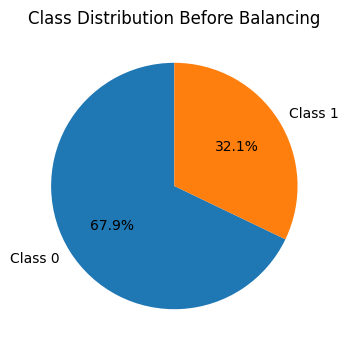

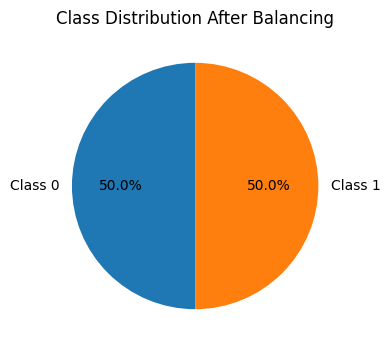

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils import resample

# Display the column names in the scaled dataset
print(scaled_data.columns)

# Define the target column name
target_column = 'Target'

# Convert continuous target values into binary classes if needed
if scaled_data[target_column].dtype != 'object' and scaled_data[target_column].dtype != 'bool':
    # Convert values greater than 0 to class 1, and values less than or equal to 0 to class 0
    scaled_data[target_column] = (scaled_data[target_column] > 0).astype(int)

# Split the dataset into two classes based on the target column
class_0 = scaled_data[scaled_data[target_column] == 0]
class_1 = scaled_data[scaled_data[target_column] == 1]

# Check whether the dataset is imbalanced
if len(class_0) != len(class_1):
    # Identify the majority and minority classes
    minority_class = class_1 if len(class_0) > len(class_1) else class_0
    majority_class = class_0 if len(class_0) > len(class_1) else class_1

    # Prepare the feature matrix and target vector
    X = scaled_data.drop(columns=[target_column])
    y = scaled_data[target_column]

    # Create a Gradient Boosting classifier
    boosting_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

    # Train the model on the full dataset
    boosting_model.fit(X, y)

    # Predict class probabilities
    y_proba = boosting_model.predict_proba(X)

    # Set the number of samples required for balancing
    n_samples = len(majority_class)

    # Oversample the minority class to match the majority class size
    sampled_minority = resample(
        minority_class,
        replace=True,
        n_samples=n_samples,
        random_state=42
    )

    # Combine the majority class with the oversampled minority class
    balanced_data = (
        pd.concat([majority_class, sampled_minority])
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

else:
    # Keep the original dataset if it is already balanced
    balanced_data = scaled_data
    print("Dataset is already balanced.")

# Plot the class distribution before balancing
before_counts = scaled_data[target_column].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    before_counts,
    labels=['Class 0', 'Class 1'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Class Distribution Before Balancing')
plt.show()

# Plot the class distribution after balancing
after_counts = balanced_data[target_column].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    after_counts,
    labels=['Class 0', 'Class 1'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Class Distribution After Balancing')
plt.show()

# Feature Selection
*	Identifying the most relevant features for the task using techniques such as correlation analysis, mutual information, or advanced methods like Recursive Feature Elimination (RFE).

*	Justifying the choice of features and their impact on model performance


Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

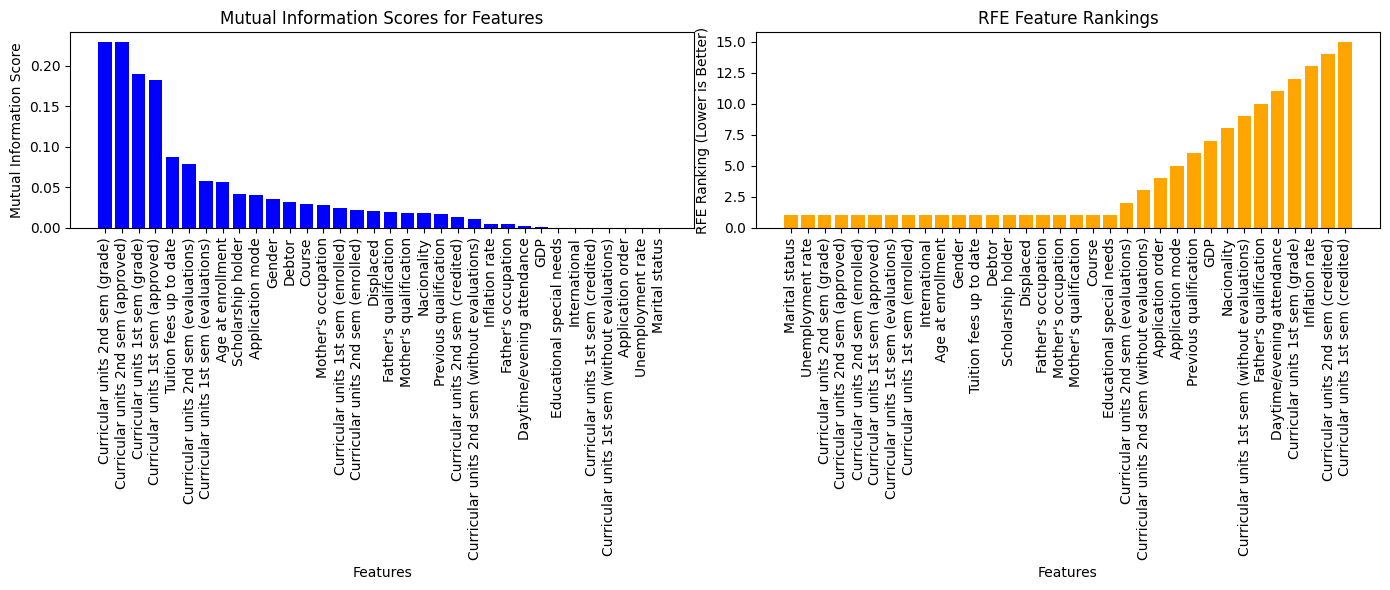

Performance Comparison:
Mutual Information - Accuracy: 0.85, Precision: 0.84
RFE - Accuracy: 0.85, Precision: 0.84

Mutual Information produces the best feature set.

Selected Features: ['Nacionality', "Mother's qualification", "Father's qualification", 'Displaced', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (enrolled)', "Mother's occupation", 'Course', 'Debtor', 'Gender', 'Application mode', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)', 'Tuition fees up to date', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
import numpy as np

# تأكد من أسماء الأعمدة
print(balanced_data.columns)

# Extract features (X) and target (y) from the original, unscaled balanced_data
X = balanced_data.drop(columns=['Target'])
y = balanced_data['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Selection: Mutual Information
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_selected_features = list(X_train.columns[np.argsort(mi_scores)[-20:]])

# Feature Selection: RFE with Logistic Regression
rfe_model = LogisticRegression(max_iter=1000, random_state=42)
rfe_selector = RFE(estimator=rfe_model, n_features_to_select=20)
rfe_selector.fit(X_train, y_train)
rfe_selected_features = list(X_train.columns[rfe_selector.support_])

# Print top selected features Mutual Information Features
X_train_mi = X_train[mi_selected_features]
X_test_mi = X_test[mi_selected_features]

# Features selected by RFE
X_train_rfe = X_train[rfe_selected_features]
X_test_rfe = X_test[rfe_selected_features]

# Initialize Logistic Regression Model
model = LogisticRegression(random_state=42)

# Train and Evaluate Model on MI-selected Features
model.fit(X_train_mi, y_train)
y_pred_mi = model.predict(X_test_mi)
accuracy_mi = accuracy_score(y_test, y_pred_mi)
precision_mi = precision_score(y_test, y_pred_mi)

# Train and Evaluate Model on RFE-selected Features
model.fit(X_train_rfe, y_train)
y_pred_rfe = model.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test,
y_pred_rfe)
precision_rfe = precision_score(y_test, y_pred_rfe)

# Sort MI scores
sorted_indices_mi = np.argsort(mi_scores)[::-1]
sorted_mi_scores = mi_scores[sorted_indices_mi]

# Sort RFE feature rankings
rfe_ranking = rfe_selector.ranking_
sorted_indices_rfe = np.argsort(rfe_ranking)  # Sort by ranking (lower is better)
sorted_rfe_scores = rfe_ranking[sorted_indices_rfe]

# Plot MI scores
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(range(len(sorted_mi_scores)), sorted_mi_scores, color='blue')
plt.xticks(range(len(sorted_mi_scores)), X_train.columns[sorted_indices_mi], rotation=90)
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.title('Mutual Information Scores for Features')

# Plot RFE rankings
plt.subplot(1, 2, 2)
plt.bar(range(len(sorted_rfe_scores)), sorted_rfe_scores, color='orange')
plt.xticks(range(len(sorted_rfe_scores)), X_train.columns[sorted_indices_rfe], rotation=90)
plt.xlabel('Features')
plt.ylabel('RFE Ranking (Lower is Better)')
plt.title('RFE Feature Rankings')

plt.tight_layout()
plt.show()

# Print Results
print("Performance Comparison:")
print(f"Mutual Information - Accuracy: {accuracy_mi:.2f}, Precision: {precision_mi:.2f}")
print(f"RFE - Accuracy: {accuracy_rfe:.2f}, Precision: {precision_rfe:.2f}")

# Choose the best feature set based on accuracy
if precision_mi > precision_rfe:
    print("\nMutual Information produces the best feature set.")
    best_features = mi_selected_features
elif precision_rfe > precision_mi:
    print("\nRFE produces the best feature set.")
    best_features = rfe_selected_features
else:
    print("\nAll Feature Selection methods have similar performance.")
    best_features = mi_selected_features

# Choose the feature set based on your preference or performance
print("\nSelected Features:", best_features)


# Machine Learning Models

# k-nearest neighbors (KNN)


Best Hyperparameters for KNN: k=19, weights=distance, metric=manhattan

Accuracy for Optimized KNN: 0.92

Confusion Matrix for KNN:
[[563  32]
 [ 66 541]]


<Figure size 800x600 with 0 Axes>

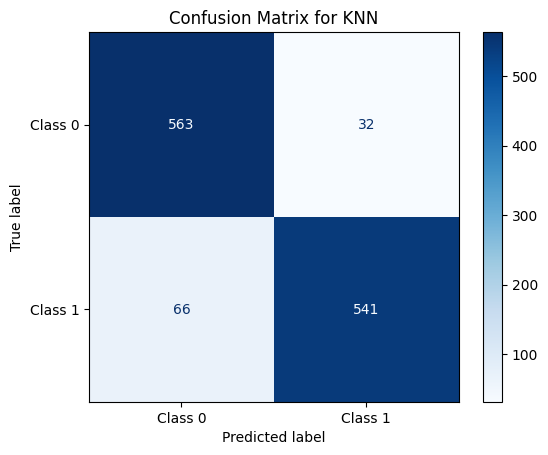


Recall for KNN (per class): [0.94621849 0.89126853]

Average Recall for KNN: 0.9187435105838051

Training K-Nearest Neighbors Model with Mutual Information Features...


K-Nearest Neighbors Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       595
           1       0.94      0.89      0.92       607

    accuracy                           0.92      1202
   macro avg       0.92      0.92      0.92      1202
weighted avg       0.92      0.92      0.92      1202


Accuracy for KNN: 0.92, Precision: 0.94, Recall: 0.92, F1-score: 0.92

Recall for KNN (per class):
Class 0: 0.9462
Class 1: 0.8913

Average Recall for KNN: 0.9187435105838051


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
#  Prepare training and test sets using the best features**
X_train_best, X_test_best = X_train[best_features], X_test[best_features]

#  Find the best K value for KNN using GridSearchCV**
param_grid_knn = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_best, y_train)

best_k = grid_knn.best_params_['n_neighbors']
best_weight = grid_knn.best_params_['weights']
best_metric = grid_knn.best_params_['metric']

print(f"\nBest Hyperparameters for KNN: k={best_k}, weights={best_weight}, metric={best_metric}")

# Train KNN with the best hyperparameters**
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights=best_weight, metric=best_metric)
knn_best.fit(X_train_best, y_train)

#  Validate the optimized KNN model**
y_pred_knn = knn_best.predict(X_test_best)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy for Optimized KNN: {accuracy_knn:.2f}")

#  Compute and Plot Confusion Matrix**
def plot_confusion_matrix(conf_matrix, model_name, target_names):
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

# Confusion matrix for KNN
target_names = ["Class 0", "Class 1"]
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix for KNN:")
print(conf_matrix_knn)
plot_confusion_matrix(conf_matrix_knn, "KNN", target_names)

#  Compute Recall Scores**
recall_knn = recall_score(y_test, y_pred_knn, average=None)
print("\nRecall for KNN (per class):", recall_knn)

average_recall_knn = recall_score(y_test, y_pred_knn, average='macro')
print("\nAverage Recall for KNN:", average_recall_knn)

#  Train KNN with Best Features from MI**
print("\nTraining K-Nearest Neighbors Model with Mutual Information Features...\n")
knn_fre = KNeighborsClassifier(n_neighbors=best_k, weights=best_weight, metric=best_metric)
knn_fre.fit(X_train_best, y_train)

# Make predictions using RFE feature set
knn_predictions_fre = knn_fre.predict(X_test_best)

# Evaluate model with FRE feature set
print("\nK-Nearest Neighbors Classification Report :")
print(classification_report(y_test, knn_predictions_fre))

# Compute Scores**
average_recall_knn = recall_score(y_test, y_pred_knn, average='macro')

# Calculate f1_score for KNN:
f1_score_knn = f1_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
print(f"\nAccuracy for KNN: {accuracy_knn:.2f}, Precision: {precision_knn:.2f}, Recall: {average_recall_knn:.2f}, F1-score: {f1_score_knn:.2f}")

# Calculate recall for each class separately
recall_knn_class_0 = recall_score(y_test, y_pred_knn, average=None, labels=[0])
recall_knn_class_1 = recall_score(y_test, y_pred_knn, average=None, labels=[1])

print("\nRecall for KNN (per class):")
print(f"Class 0: {recall_knn_class_0[0]:.4f}")
print(f"Class 1: {recall_knn_class_1[0]:.4f}")

# avarege recall of KNN
average_recall_knn = recall_score(y_test, y_pred_knn, average='macro')
print("\nAverage Recall for KNN:", average_recall_knn)


 # SVM


Best Hyperparameters for SVM: C=100, kernel=rbf, gamma=scale

Accuracy for Optimized SVM: 0.90

SVM Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       595
           1       0.90      0.90      0.90       607

    accuracy                           0.90      1202
   macro avg       0.90      0.90      0.90      1202
weighted avg       0.90      0.90      0.90      1202


Confusion Matrix for SVM:
[[535  60]
 [ 60 547]]


<Figure size 800x600 with 0 Axes>

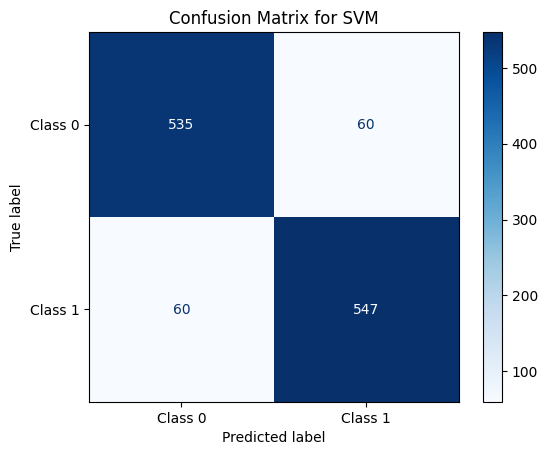


Accuracy for SVM: 0.90, Precision: 0.90, Recall: 0.90, F1-score: 0.90

Recall for SVM (per class):
Class 0: 0.8992
Class 1: 0.9012

Average Recall for SVM: 0.9001564381930697


In [ ]:
from sklearn.svm import SVC

#  Define SVM hyperparameter grid
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_best, y_train)

#  Get the best hyperparameters
best_C = grid_svm.best_params_['C']
best_kernel = grid_svm.best_params_['kernel']
best_gamma = grid_svm.best_params_['gamma']

print(f"\nBest Hyperparameters for SVM: C={best_C}, kernel={best_kernel}, gamma={best_gamma}")

# Train SVM with the best parameters
svm_best = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma)
svm_best.fit(X_train_best, y_train)

# Validate the optimized SVM model
y_pred_svm = svm_best.predict(X_test_best)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAccuracy for Optimized SVM: {accuracy_svm:.2f}")

target_names = ["Class 0", "Class 1"]
#  Compute and Plot Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Evaluate model with FRE feature set
print("\nSVM Classification Report :")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix for SVM:")
print(conf_matrix_svm)
plot_confusion_matrix(conf_matrix_svm, "SVM", target_names)

# Compute Scores
average_recall_SVM = recall_score(y_test, y_pred_svm, average='macro')

# Calculate f1_score for SVM:
f1_score_svm = f1_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
print(f"\nAccuracy for SVM: {accuracy_svm:.2f}, Precision: {precision_svm:.2f}, Recall: {average_recall_SVM:.2f}, F1-score: {f1_score_svm:.2f}")

# Calculate recall for each class separately
recall_svm_class_0 = recall_score(y_test, y_pred_svm, average=None, labels=[0])
recall_svm_class_1 = recall_score(y_test, y_pred_svm, average=None, labels=[1])

print("\nRecall for SVM (per class):")
print(f"Class 0: {recall_svm_class_0[0]:.4f}")
print(f"Class 1: {recall_svm_class_1[0]:.4f}")

# avarege recall of KNN
average_recall_svm = recall_score(y_test, y_pred_svm, average='macro')
print("\nAverage Recall for SVM:", average_recall_svm)


#Decision Tree


=== Gini-based Tree: Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.85      0.94      0.89       595
     Class 1       0.93      0.84      0.89       607

    accuracy                           0.89      1202
   macro avg       0.89      0.89      0.89      1202
weighted avg       0.89      0.89      0.89      1202

=== Entropy-based Tree: Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.88      0.92      0.90       595
     Class 1       0.92      0.87      0.90       607

    accuracy                           0.90      1202
   macro avg       0.90      0.90      0.90      1202
weighted avg       0.90      0.90      0.90      1202



<Figure size 800x600 with 0 Axes>

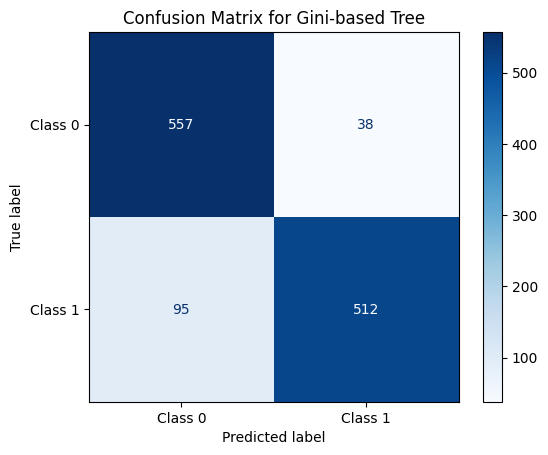

<Figure size 800x600 with 0 Axes>

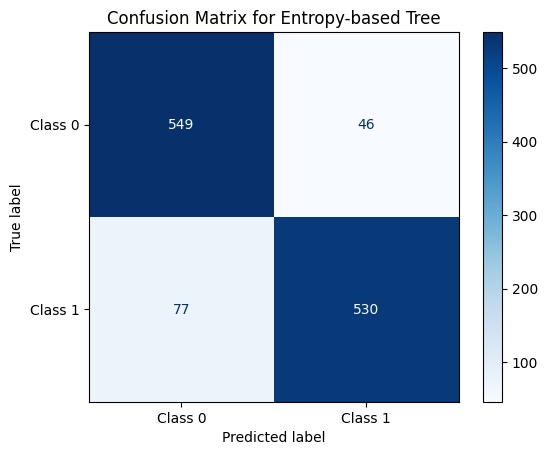


Gini-based Tree  recall class 0:  0.9361, recall class 1: 0.8435, Accuracy:  0.8894 ,precision: 0.8930, F1- score: 0.8892

Entropy-based Tree  recall class 0:  0.9227, recall class 1: 0.8731, Accuracy:  0.8977 ,precision: 0.8988, F1 score: 0.8976

Entropy-based Tree produced the best model.

Average Recall for Gini-based Tree: 0.8898135201362258
Average Recall for Entropy-based Tree: 0.8979178491825066


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score ,classification_report,  confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Define class labels (adjust based on dataset)
target_names = ["Class 0", "Class 1"]

# Train Decision Trees
# Gini-based Tree
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)

# Entropy-based Tree (Information Gain)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)

# Evaluate and Print Classification Reports
y_pred_gini = clf_gini.predict(X_test)
y_pred_entropy = clf_entropy.predict(X_test)

print("=== Gini-based Tree: Classification Report ===")
print(classification_report(y_test, y_pred_gini, target_names=target_names))

print("=== Entropy-based Tree: Classification Report ===")
print(classification_report(y_test, y_pred_entropy, target_names=target_names))


# Confusion Matrix Plotting Function
def plot_confusion_matrix(conf_matrix, model_name, class_labels):
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

# Plot Confusion Matrices
conf_matrix_gini = confusion_matrix(y_test, y_pred_gini)
conf_matrix_entropy = confusion_matrix(y_test, y_pred_entropy)

plot_confusion_matrix(conf_matrix_gini, "Gini-based Tree", target_names)
plot_confusion_matrix(conf_matrix_entropy, "Entropy-based Tree", target_names)

# Compare Accuracy
accuracy_gini = accuracy_score(y_test, y_pred_gini)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

precision_gini = precision_score(y_test, y_pred_gini, average='weighted')
precision_entropy = precision_score(y_test, y_pred_entropy, average='weighted')

recall_gini = recall_score(y_test, y_pred_gini, average='weighted')
recall_entropy = recall_score(y_test, y_pred_entropy, average='weighted')

f1_gini = f1_score(y_test, y_pred_gini, average='weighted')
f1_entropy = f1_score(y_test, y_pred_entropy, average='weighted')

# Calculate recall for each class separately
recall_gini_class_0 = recall_score(y_test, y_pred_gini, average=None, labels=[0])
recall_gini_class_1 = recall_score(y_test, y_pred_gini, average=None, labels=[1])

recall_entropy_class_0 = recall_score(y_test, y_pred_entropy, average=None, labels=[0])
recall_entropy_class_1 = recall_score(y_test, y_pred_entropy, average=None, labels=[1])

print(f"\nGini-based Tree  recall class 0:  {recall_gini_class_0[0]:.4f}, recall class 1: {recall_gini_class_1[0]:.4f}, Accuracy:  {accuracy_gini:.4f} ,precision: {precision_gini:.4f}, F1- score: {f1_gini:.4f}")

print(f"\nEntropy-based Tree  recall class 0:  {recall_entropy_class_0[0]:.4f}, recall class 1: {recall_entropy_class_1[0]:.4f}, Accuracy:  {accuracy_entropy:.4f} ,precision: {precision_entropy:.4f}, F1 score: {f1_entropy:.4f}")


# choose the highest between the gini-based and Entropy-based
if accuracy_gini > accuracy_entropy:
    print("\nGini-based Tree produced the best model.")
elif accuracy_entropy > accuracy_gini:
    print("\nEntropy-based Tree produced the best model.")
else:
    print("\nBoth models have similar performance.")

# tree recall
average_recall_gini = recall_score(y_test, y_pred_gini, average='macro')
average_recall_entropy = recall_score(y_test, y_pred_entropy, average='macro')
print("\nAverage Recall for Gini-based Tree:", average_recall_gini)
print("Average Recall for Entropy-based Tree:", average_recall_entropy)

Best Parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== Optimized Decision Tree: Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       595
           1       0.92      0.87      0.90       607

    accuracy                           0.90      1202
   macro avg       0.90      0.90      0.90      1202
weighted avg       0.90      0.90      0.90      1202



<Figure size 800x600 with 0 Axes>

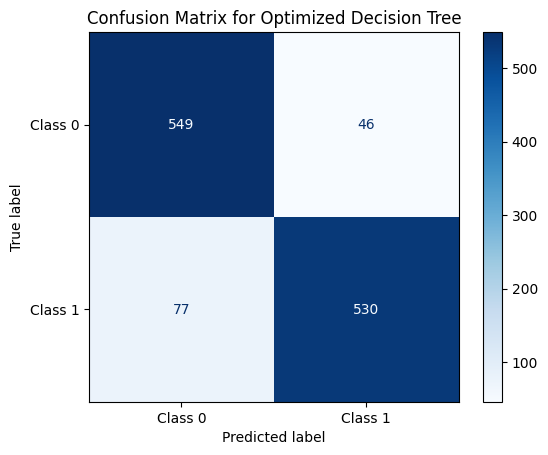

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Perform Grid Search with 5-fold cross-validation, optimizing for recall
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall_weighted',
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best model
best_tree = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate the optimized model
y_pred_best = best_tree.predict(X_test)
print("\n=== Optimized Decision Tree: Classification Report ===")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
plot_confusion_matrix(conf_matrix_best, "Optimized Decision Tree", target_names)

# Algorithm Comparison


Performance Comparison:


KNN - Accuracy: 0.92, Precision:, 0.94, recall 0.92, f1-score: 0.9169491525423729

SVM - Accuracy: 0.90, Precision: 0.90,recall 0.90, f1-score: 0.9011532125205931

Decision Tree - Accuracy: 0.89, Precision: 0.89, recall 0.89, f1-score: 0.8891543677749861

So, KNN produced the best model.


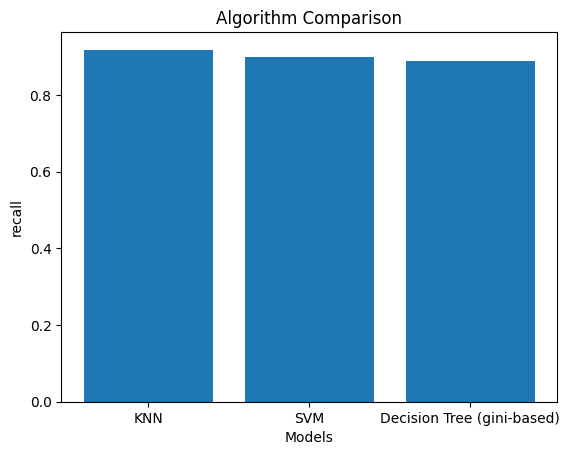

In [ ]:
# Print results
print("\nPerformance Comparison:\n")
print(f"\nKNN - Accuracy: {accuracy_knn:.2f}, Precision:, {precision_knn:.2f}, recall {average_recall_knn:.2f}, f1-score: {f1_score_knn}")
print(f"\nSVM - Accuracy: {accuracy_svm:.2f}, Precision: {precision_svm:.2f},recall {average_recall_SVM:.2f}, f1-score: {f1_score_svm}")
print(f"\nDecision Tree - Accuracy: {accuracy_gini:.2f}, Precision: {precision_gini:.2f}, recall {recall_gini:.2f}, f1-score: {f1_gini}")

#print the highest score
if accuracy_knn > accuracy_svm and accuracy_knn > accuracy_gini:
    print("\nSo, KNN produced the best model.")
    best_model = "KNN"
elif accuracy_svm > accuracy_knn and accuracy_svm > accuracy_gini:
    print("\nSo, SVM produced the best model.")
    best_model = "SVM"

elif accuracy_gini > accuracy_knn and accuracy_gini > accuracy_svm:
    print("\nSo, Decision Tree produced the best model.")
    best_model = "Decision Tree"
else:
    print("\nAll models have similar performance.")
    best_model = "All models"

# bar chart of the 3 algorithms
import matplotlib.pyplot as plt

models = ['KNN', 'SVM', 'Decision Tree (gini-based)']
accuracy = [accuracy_knn, accuracy_svm, accuracy_gini]

plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('recall')
plt.title('Algorithm Comparison')
plt.show()